In [ ]:
import pandas as pd
from numba import jit, njit, prange
import numpy as np
from loaders import loader, load_references, load_strong

In [ ]:
references = load_references()

strong = load_strong()
sept = loader("sept")
sept["str_i"] = [int(s) if s[0] != "C" else -int(s[1:]) for s in sept["str"]]

In [ ]:
references.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       4797, 4798, 4799, 4800, 4801, 4802, 4803, 4804, 4805, 4806],
      dtype='int64', length=4807)

In [ ]:
sept["referenced"] = False
for i, (start, end) in enumerate(references[["ostart", "oend"]].values):
    sept.loc[sept.index[start:end], "referenced"] = True
    references.loc[i, "text"] = " ".join(
        sept.loc[sept.index[start:end], "str_i"].astype(str)
    )
sept["referenced"].value_counts()

referenced
False    461618
True      13782
Name: count, dtype: int64

In [ ]:
referenced = sept.query("referenced")
not_referenced = sept.query("~referenced")

In [ ]:
# variable names from ChatGPT, apologies
@njit(parallel=True)
def get_zscores(referenced_str, not_referenced_str, all_words, a0):
    zscores = np.empty(all_words.shape, dtype=float)
    total_len = len(referenced_str) + len(not_referenced_str)
    for i in prange(len(all_words)):
        word = all_words[i]
        c1 = (referenced_str == word).sum()
        c2 = (not_referenced_str == word).sum()
        fw = c1 + c2
        aw = fw / total_len * a0
        p1 = (c1 + aw) / (len(referenced_str) + a0 - fw)
        p2 = (c2 + aw) / (len(not_referenced_str) + a0 - fw)
        logodds = np.log(p1 / (1 - p1)) - np.log(p2 / (1 - p2))
        variance = 1 / (c1 + aw) + 1 / (c2 + aw)
        zscores[i] = logodds / np.sqrt(variance)
    zscores[np.isnan(zscores)] = 0
    return zscores

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(references["text"])
all_words = vectorizer.get_feature_names_out().astype(int)

In [ ]:
"""params = pd.DataFrame(columns=['a0', 'n', 'k', 's'], dtype=int)
for a0 in [10, 50, 100, 500, 1000]:
    print(a0)
    scores = get_zscores(referenced['str_i'].values, not_referenced['str_i'].values, all_words, a0)
    sort_idx = np.argsort(scores)
    for n_features in [5, 10, 50, 100, 614]:
        to_use = sort_idx[-n_features:]
        features = X[:, to_use]
        for k in range(2, 8):
            kmeans = KMeans(n_clusters=k)
            params.loc[len(params)] = [a0, n_features, k, silhouette_score(features, kmeans.fit_predict(features))]"""

"params = pd.DataFrame(columns=['a0', 'n', 'k', 's'], dtype=int)\nfor a0 in [10, 50, 100, 500, 1000]:\n    print(a0)\n    scores = get_zscores(referenced['str_i'].values, not_referenced['str_i'].values, all_words, a0)\n    sort_idx = np.argsort(scores)\n    for n_features in [5, 10, 50, 100, 614]:\n        to_use = sort_idx[-n_features:]\n        features = X[:, to_use]\n        for k in range(2, 8):\n            kmeans = KMeans(n_clusters=k)\n            params.loc[len(params)] = [a0, n_features, k, silhouette_score(features, kmeans.fit_predict(features))]"

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
"""fig, axes = plt.subplots(nrows=3)
for i, param in enumerate(['a0', 'k', 'n']):
    params.groupby(param)['s'].agg('mean').sort_index().plot.bar(ax=axes[i])
fig.set_size_inches(8, 10)
plt.tight_layout()"""

"fig, axes = plt.subplots(nrows=3)\nfor i, param in enumerate(['a0', 'k', 'n']):\n    params.groupby(param)['s'].agg('mean').sort_index().plot.bar(ax=axes[i])\nfig.set_size_inches(8, 10)\nplt.tight_layout()"

In [ ]:
# params['s'].max()

In [ ]:
scores = get_zscores(
    referenced["str_i"].values, not_referenced["str_i"].values, all_words, 10
)
sort_idx = np.argsort(scores)
to_use = sort_idx[-5:]
features = X[:, to_use]
k = 3
kmeans = KMeans(n_clusters=k)
references["cluster"] = kmeans.fit_predict(features).astype(str)

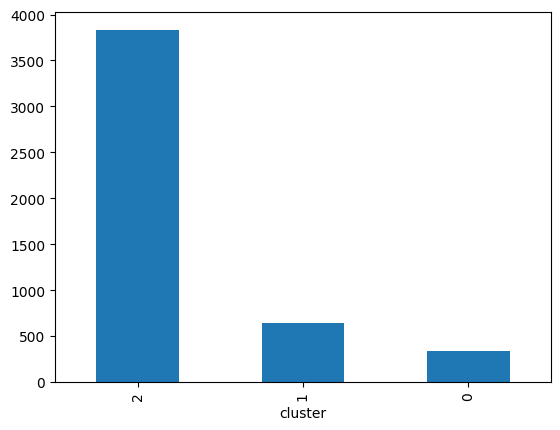

In [ ]:
references["cluster"].value_counts().plot.bar();

In [ ]:
strong.loc[all_words[to_use].astype(str)]

,original,def
str,,
1565,ἐκεῖνος,"he, it, the other (same), selfsame, that (same..."
3962,πατήρ,"father, parent"
2316,θεός,"X exceeding, God, god(-ly, -ward)"
4771,σύ,thou
1722,ἐν,"about, after, against, + almost, X altogether,..."


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
references[["x", "y", "z"]] = pca.fit_transform(features)

In [ ]:
import plotly.express as px

In [ ]:
px.scatter_3d(references, x="x", y="y", z="z", color="cluster")

In [ ]:
import plotly.express as px
import numpy as np
import imageio.v2 as imageio
import os

# --- Your 3D scatter ---
fig = px.scatter_3d(references, x="x", y="y", z="z", color="cluster")

# Basic clean layout
fig.update_layout(
    scene=dict(
        xaxis=dict(visible=True),
        yaxis=dict(visible=True),
        zaxis=dict(visible=True),
    ),
    margin=dict(l=0, r=0, b=0, t=0),
)

# --- Generate rotation frames ---
angles = np.linspace(0, 360, 60)  # 60 frames for one full rotation
filenames = []

for i, angle in enumerate(angles):
    # Update camera position
    camera = dict(
        eye=dict(
            x=2 * np.cos(np.radians(angle)),
            y=2 * np.sin(np.radians(angle)),
            z=0.6,  # tilt up a bit
        )
    )
    fig.update_layout(scene_camera=camera)

    # Save frame
    filename = f"frame_{i:03d}.png"
    fig.write_image(filename, scale=2)
    filenames.append(filename)

# --- Stitch into GIF ---
with imageio.get_writer("rotation.gif", mode="I", duration=0.05) as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

# --- Clean up frame images ---
for filename in filenames:
    os.remove(filename)

print("✅ rotation.gif created successfully!")

✅ rotation.gif created successfully!


In [ ]:
import pickle

references["cluster"] = references["cluster"].astype(int)
with open("./pickles/clustered_references.pickle", "wb") as f:
    pickle.dump(references, f)